# Titanic - Machine Learning from Disaster

| Variable  | Definition                                   | Key                                      |
|-----------|----------------------------------------------|------------------------------------------|
| survival  | Survival                                     | 0 = No, 1 = Yes                          |
| pclass    | Ticket class                                 | 1 = 1st, 2 = 2nd, 3 = 3rd                |
| sex       | Sex                                          |                                          |
| age       | Age in years                                 |                                          |
| sibsp     | # of siblings / spouses aboard the Titanic   |                                          |
| parch     | # of parents / children aboard the Titanic   |                                          |
| ticket    | Ticket number                                |                                          |
| fare      | Passenger fare                               |                                          |
| cabin     | Cabin number                                 |                                          |
| embarked  | Port of Embarkation                          | C = Cherbourg, Q = Queenstown, S = Southampton |

---
## Import Libraries

In [77]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV,
    StratifiedKFold
) 

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier
)

from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             ConfusionMatrixDisplay,
                             accuracy_score
)

---
## Read Files

In [78]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

---
## Explore the data

In [79]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [80]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Based on this information this  gives us an idea of what might be interesting and what seems likely to be unnecessary. 

Things that might be unnecessary: 
- PassengerID (just a row number)
- Cabin (too many null values, drop it)

This might be interesting to keep: 
- Survived (target)
- Pclass (people with higher Title have higher chance of survival?)
- Age (numerical variable)
SibSp/Parch (family size might matter)

In [81]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


Interesting notes: 
- min age => 0: youngest passenger was baby
- max age => 80 
- Pclass => mean: 2 class
- Survived => mean: 38% survived

A summary of all the non-numeric (text/categorical) colmuns in the dataframe:

In [82]:
# A summary of the categorical (text) columns
df_train.describe(include='O').T

C:\Users\fifif\AppData\Local\Temp\ipykernel_6232\3862125620.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_train.describe(include='O').T


,count,unique,top,freq
Name,891,891,"Braund, Mr. Owen Harris",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,G6,4
Embarked,889,3,S,644


Interesting note: 
- We see that ticket has 681 unique values from the 891 tickets in total which means that there are doubles
- we also see that Cabin also has a difference in the unique values, but this makes sense because multiple passengers can be assigned to the same cabin. 
- Sex has only 2 unique values, but this makes sense since with either male or female
- Emarked has 3 unique values which are the different ports, note that Southhampton was the most common port

Look at the missing values across all columns: 

In [83]:
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

There are missing values in:
-  age => 177 missing 
- cabin => has the highest amount of missing values with 687 missing values
- embarked => only two missing values 

This might be interesting if we decide to remove certain columns or fill those in. 

### Correlation matrix

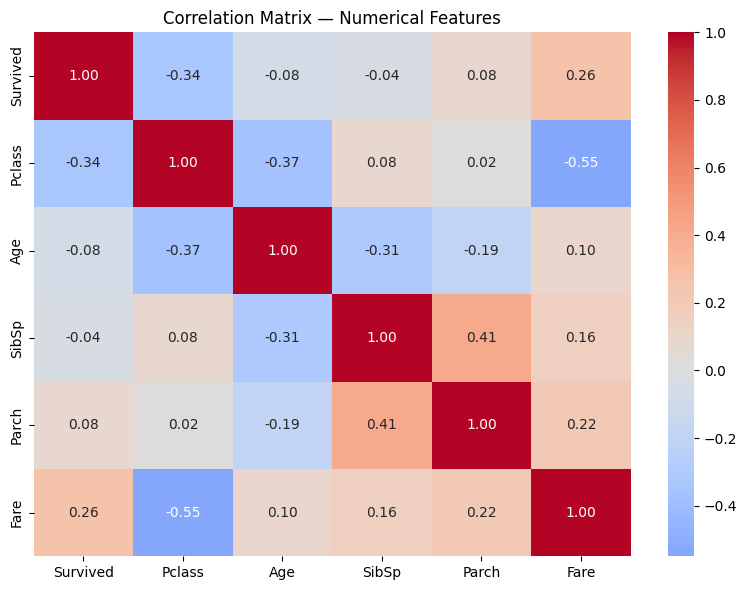

In [84]:
numerical_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

plt.figure(figsize=(8, 6))
sns.heatmap(
    df_train[numerical_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()

Note:
- Survived vs Pclass: -0.34, negative correlation
- survived vs fare: 0.26, positive correlation, higher fare means higher survival
- Pclass vs Fare: -0.55, negative correlation
- SibSp vs Parch: 0.51, positive correlation, have correlation interesting to keep them together

### Outlier detection

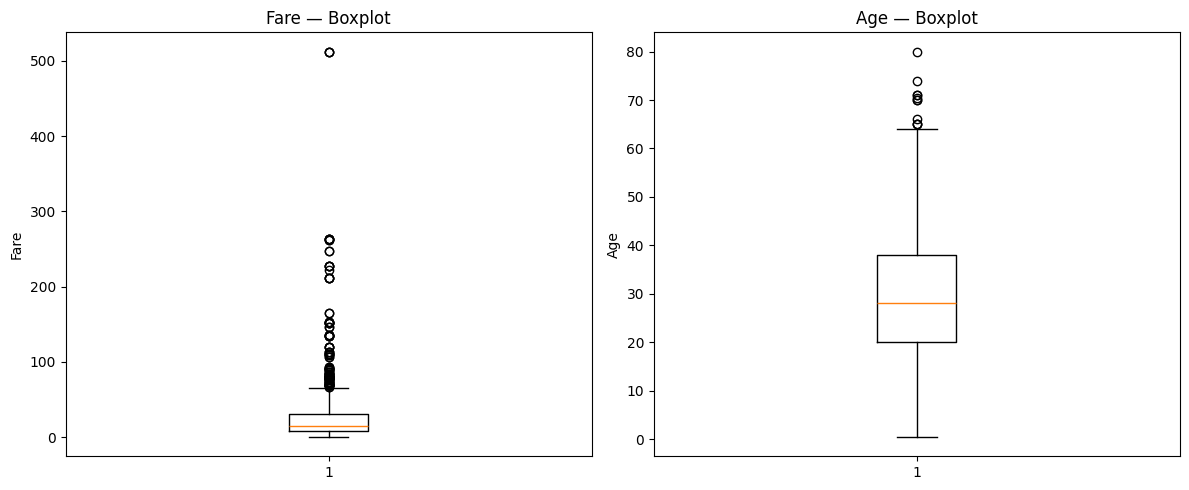

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(df_train['Fare'].dropna())
axes[0].set_title('Fare — Boxplot')
axes[0].set_ylabel('Fare')

axes[1].boxplot(df_train['Age'].dropna())
axes[1].set_title('Age — Boxplot')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

---
##  Exploratory Data Analysis - Classes Likey to survive? 

Guess: 
Before divind into the data, it's good to guess what factors might have influenced the survival chances: 
- Pclass: Higher class passenger, may have had a higher chance to survive based on where they were located and perhaps had a faster access to the deck and the lifeboats

- Sex: It has always been known that women and children were prioritised in disasters ("Women and children first"), but elderly too. 

- Age: Same thing for age, it impacts the priority so children and elderly might have had higher chances to survive. 

- Family Size: Travelling alone or with a family will affect your survival chances

#### Survival based on Gender

In [86]:
#Look if women actualy had a higher survival rate than men
df_train.groupby(['Sex'], as_index=False)['Survived'].mean()


,Sex,Survived
0,female,0.742038
1,male,0.188908


Females had a higher survival rate with 74% compared to males where it's as low as 19%. This also confirmes our guess that Sex impacts your survival chances. 

#### Survival based on Pclass

In [87]:
#Look if class actually had an impact on survival
df_train.groupby(['Pclass'], as_index=False)['Survived'].mean()

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


Also confirms our guess: 
- 62% of passengers who survived were sitted in the first class. 
- 47% of passengers who survived were from the second class. 
- only 24% of passengers who survived came from the third class. 

This confirms that the higher the class, the higher the chance of survival. This is likely due to the location to the deck.

#### Survival based on the amount of SibSp (Sibling/Spouses)

In [88]:
df_train.groupby(['SibSp'], as_index=False)['Survived'].mean()

,SibSp,Survived
0,0,0.345395
1,1,0.535885
2,2,0.464286
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


#### Survival based on Parch (Parents/Children)

In [89]:
df_train.groupby(['Parch'], as_index=False)['Survived'].mean()

,Parch,Survived
0,0,0.343658
1,1,0.550847
2,2,0.500000
3,3,0.600000
4,4,0.000000
5,5,0.200000
6,6,0.000000


##### Combine SibSp and Parch into Family Size

It's better to look at the Family Size in broad terms rather than looking at SibSp and Parch separately. 

In [90]:
df_train['FamilySize'] = df_train['SibSp'] + df_train['Parch'] + 1
df_test['FamilySize'] = df_test['SibSp'] + df_test['Parch'] + 1

In [91]:
df_train.groupby('FamilySize')['Survived'].mean()*100

FamilySize
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64

Note:
- People alone have a lower survival rate 30%
- Small families (2-4) had the highest survival rate between 55% and 72%
- Large families (5+) had lower survival rate, lower than alone

This confirms that travelling with a small/midsize family gives the best survival rate. 

In [92]:
#Grouping family size into categories 
family_map = {1: "Alone", 2: "Small", 3: "Small", 4: "Small", 5: "Medium", 6: "Medium", 7: "Large", 8: "Large", 11: "Large"}

In [93]:
df_train['Family_Size_Grouped'] = df_train['FamilySize'].map(family_map)
df_test['Family_Size_Grouped'] = df_test['FamilySize'].map(family_map)

In [94]:
df_train.groupby(['Family_Size_Grouped'], as_index=False)['Survived'].mean()

,Family_Size_Grouped,Survived
0,Alone,0.303538
1,Large,0.160000
2,Medium,0.162162
3,Small,0.578767


#### Survival based on Embarked

In [95]:
df_train.groupby(['Embarked'], as_index=False)['Survived'].mean()

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.336957


Based on embarkement port we can see: 
- C = Cherbourg has the highest survival chance with 55%
- S = Southhampton has the lowest survival chance with 34%

but why? How does the port of embarkement influence chance of survival? 
Is this merely by chance or is this influenced by the class and  from where they departed? 


Check if this is true? 

Inspired by: https://pubmed.ncbi.nlm.nih.gov/3520835/

Note: This hypothesis was explored witht the asistance of AI (ChatGPT)

In [96]:
pd.crosstab(df_train['Embarked'], df_train['Pclass'])

Pclass,1,2,3
Embarked,,,
C,85,17,66
Q,2,3,72
S,127,164,353


In [97]:
pd.crosstab(
    df_train['Embarked'],
    df_train['Pclass'],
    normalize='index'
) * 100

Pclass,1,2,3
Embarked,,,
C,50.595238,10.119048,39.285714
Q,2.597403,3.896104,93.506494
S,19.720497,25.465839,54.813665


In [98]:
df_train.groupby(['Embarked', 'Pclass'])['Survived'].mean() * 100

Embarked  Pclass
C         1         69.411765
          2         52.941176
          3         37.878788
Q         1         50.000000
          2         66.666667
          3         37.500000
S         1         58.267717
          2         46.341463
          3         18.980170
Name: Survived, dtype: float64

This confirms our guess: 
The higher survival rates from Cherbourg passengers is explained by their class. This means that port of embarkement is not a direct cause for survival, but rather shows the class that embarked at which port. 

Since we already know that sex strongly influences survival, let's check if the gender distribution also differs from port of embarkement.

In [99]:
pd.crosstab(
    [df_train['Embarked'], df_train['Pclass']],
    df_train['Sex'],
    normalize='index'
) * 100

Sex                 female       male
Embarked Pclass                      
C        1       50.588235  49.411765
         2       41.176471  58.823529
         3       34.848485  65.151515
Q        1       50.000000  50.000000
         2       66.666667  33.333333
         3       45.833333  54.166667
S        1       37.795276  62.204724
         2       40.853659  59.146341
         3       24.929178  75.070822

Here we can see that there were more women in Cherbough compared to Southhampton. Southampton had a higher proportion of male passengers especially in the third class. 


After some searching online it showed that southhampton was the port of departure where the majority of the crew and lower class boarded.

To add,  those who resided in the third class had lower chance of surviving because the lower-class cabines were located on the lower and forward decks which were also the furthest away from the boat where the lifeboats were.  

We can take away that the port itself does not directly determine the survival but the port mainly reflects the passengers class and gender. 

Source: https://pubmed.ncbi.nlm.nih.gov/3520835/

#### Survival based on Age

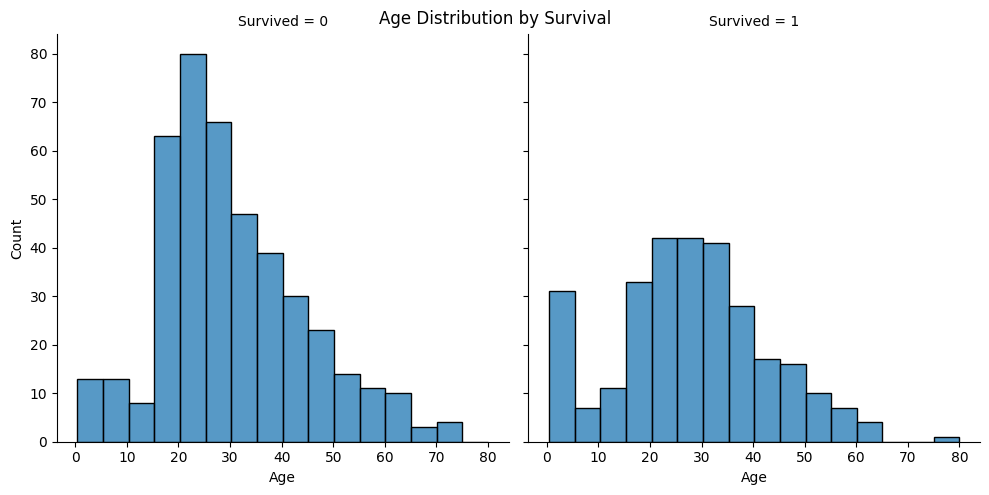

In [100]:
sns.displot(data=df_train, x='Age', col='Survived', bins=16, col_order=[0, 1])
plt.suptitle("Age Distribution by Survival")
plt.show()

In [101]:
#split age into 8 equal bins 
df_train['Age_Cut'] = pd.qcut(df_train['Age'], 8)

In [102]:
df_train.groupby(['Age_Cut'], as_index=False)['Survived'].mean()

,Age_Cut,Survived
0,"(0.419, 16.0]",0.550000
1,"(16.0, 20.125]",0.341772
2,"(20.125, 24.0]",0.367347
3,"(24.0, 28.0]",0.352941
4,"(28.0, 32.312]",0.416667
5,"(32.312, 38.0]",0.450549
6,"(38.0, 47.0]",0.329545
7,"(47.0, 80.0]",0.415730


Note: 
- Children (0-16): highest rate with 55%, confirming that children were prioritised
- Young Adults (16-24): Survival between 34-37%
- Middle aged (28-38): Survival between 42-45%n slightly higher than Young Adults
- Older passengers (38+): survival rate more on the lower side

This also confirms that age indeed played a role in survival chances, especially young children. 

#### Survival based on Fare

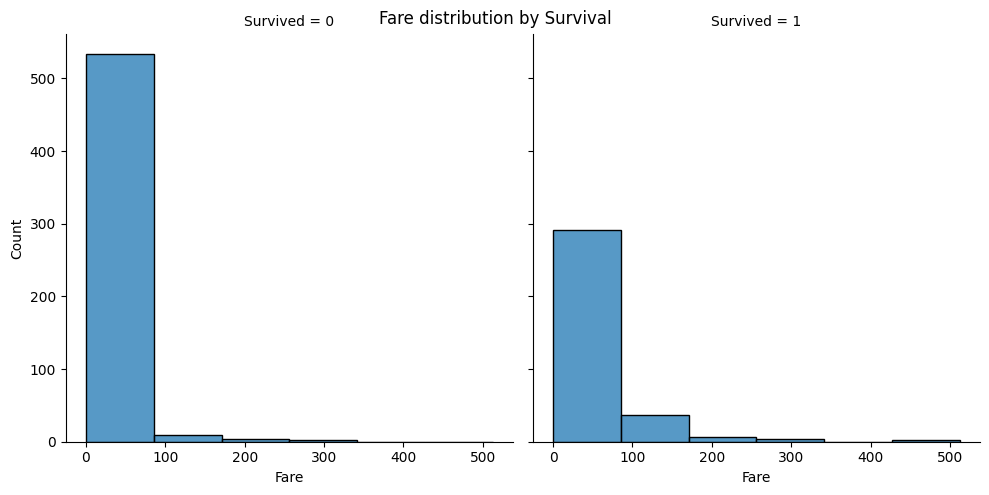

In [103]:
sns.displot(df_train, x='Fare', 
            col='Survived', 
             col_order=[0,1],
            binwidth=80, 
            height=5, 
           )

plt.suptitle("Fare distribution by Survival")
plt.show()

In [104]:
df_train['Fare_Cut'] = pd.qcut(df_train['Fare'], 6)

In [105]:
df_train.groupby(['Fare_Cut'], as_index=False)['Survived'].mean()

,Fare_Cut,Survived
0,"(-0.001, 7.775]",0.205128
1,"(7.775, 8.662]",0.190789
2,"(8.662, 14.454]",0.366906
3,"(14.454, 26.0]",0.436242
4,"(26.0, 52.369]",0.417808
5,"(52.369, 512.329]",0.697987


This shows us the price that passengers paid for the fare and what the survival was based on the price. 
 - Lowest fare (0-7.77) had 21% survival rate
 - Middle fares (8.66-26) here increased survival rate
 - Highest fares (52+) strongest survival rate

What can we take away from this?: 
As expected, those who spent at 52 dollars, meant they were in higher classes, better cabin location and thus easier acces to the lifeboats. 

#### Survival based on Title

Since Title does hold meaning, look if there were certain Titles with higher survival chance than others. 

In [106]:
df_train['Title_Cut'] = df_train['Name'].str.split(pat=",", expand=True)[1].str.split(pat=".", expand=True)[0].str.strip()
df_test['Title_Cut'] = df_test['Name'].str.split(pat=",", expand=True)[1].str.split(pat=".", expand=True)[0].str.strip()
print(df_train['Title_Cut'])

0        Mr
1       Mrs
2      Miss
3       Mrs
4        Mr
       ... 
886     Rev
887    Miss
888    Miss
889      Mr
890      Mr
Name: Title_Cut, Length: 891, dtype: str


In [107]:
df_train.groupby(['Title_Cut'], as_index=False)['Survived'].mean()

,Title_Cut,Survived
0,Capt,0.000000
1,Col,0.500000
2,Don,0.000000
3,Dr,0.428571
4,Jonkheer,0.000000
5,Lady,1.000000
6,Major,0.500000
7,Master,0.575000
8,Miss,0.697802
9,Mlle,1.000000


We can see that there is indeed a ranking in titles, but some titles do have the same meaning or are similar in ranking:

- Mrs, Miss, Mlle, Mme, Ms, Lady, Sir, The countess: all have high survival rates

- Master (young boys) : 58% survival rate, children were prioritised
- Mr: only 16% survival rate, adult males had the lowest chance of survival
- Rare titles: Dr, Rev, Col,.... 

#### Survival based on Ticket Nr

In [108]:
df_train['Ticket'].head(20)

0            A/5 21171
1             PC 17599
2     STON/O2. 3101282
3               113803
4               373450
5               330877
6                17463
7               349909
8               347742
9               237736
10             PP 9549
11              113783
12           A/5. 2151
13              347082
14              350406
15              248706
16              382652
17              244373
18              345763
19                2649
Name: Ticket, dtype: str

Looking at the ticket numbers you can see some have a prefix "PC", "A/5". While others are just numbers. 

Let's check if the ticket prefix has any meaning or useful information for survival...

In [109]:
#split the ticket and look at the first part
def extract_ticket_prefix(ticket) :
    parts = ticket.split()
    if len(parts) > 1:
        return parts[0] #=> gives us the prefix like "PC"
    else:
        return "none" # => this in the case when there is no prefix 
    
df_train['Ticket_Prefix'] = df_train['Ticket'].apply(extract_ticket_prefix)
    

In [110]:
df_train.groupby('Ticket_Prefix')['Survived'].mean().sort_values(ascending=False)

Ticket_Prefix
SW/PP         1.000000
S.W./PP       1.000000
SC            1.000000
SO/C          1.000000
F.C.C.        0.800000
SC/AH         0.666667
PP            0.666667
PC            0.650000
WE/P          0.500000
S.C./PARIS    0.500000
SC/Paris      0.500000
P/PP          0.500000
STON/O2.      0.500000
C.A.          0.481481
STON/O        0.416667
SC/PARIS      0.400000
C             0.400000
none          0.383459
SOTON/OQ      0.142857
A/5.          0.142857
CA.           0.125000
SOTON/O.Q.    0.125000
W./C.         0.111111
A/5           0.100000
A.5.          0.000000
A/4           0.000000
A./5.         0.000000
C.A./SOTON    0.000000
A4.           0.000000
A/4.          0.000000
A/S           0.000000
S.C./A.4.     0.000000
CA            0.000000
F.C.          0.000000
Fa            0.000000
S.O.P.        0.000000
S.P.          0.000000
S.O./P.P.     0.000000
S.O.C.        0.000000
SOTON/O2      0.000000
SCO/W         0.000000
W/C           0.000000
W.E.P.        0.0000

This is not super reliable because we get 0 or 100% since it's based on 1 passenger. This is not interesting to include. 

### Overall Survival Rate

In [111]:
df_train['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [112]:
survival_rate = df_train['Survived'].value_counts(normalize=True)
print((survival_rate * 100))


Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


Look at the balance between those who have survived and those who didn't.
We see that 62% did not survive whereas 38% did survive the disaster. 

### EDA Summary

Key findings: 
- Sex was the strongest predictor with females having a significant higher survival rate than males. 

- Title: Captures both sex but also social status which is also a strong predictor

- FamilySize: Higher chance of surviving when it's a small/midsize family
- Fare: Higher fare= higher survival
- Age : Children had the highest survival rate
- Embarked: not a direct cause for survival 


Features that will not be used: 

- PassengerId, Name, Ticket, Cabin: does not predict and have too many missing values
- Ticket_Prefix : Too many unique values 

---

## Modeling

In [113]:
df_train_raw = pd.read_csv("train.csv")
df_test_raw = pd.read_csv("test.csv")

### Prepare data

In [114]:
# Calculate imputation values from TRAINING data only
age_median = df_train_raw['Age'].median()
fare_median = df_train_raw['Fare'].median()
embarked_mode = df_train_raw['Embarked'].mode()[0]

def prepare_data(df, is_train=True):
    df = df.copy()
    
    # Extract and group titles
    df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.', expand=False).str.strip()
    df['Title'] = df['Title'].replace(
        ['Dr', 'Rev', 'Col', 'Major', 'Countess', 'Sir', 
         'Jonkheer', 'Lady', 'Capt', 'Don', 'Dona'], 'Rare'
    )
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
    df['Title'] = df['Title'].map({'Mr': 0, 'Rare': 1, 'Master': 2, 'Miss': 3, 'Mrs': 4})
    df['Title'] = df['Title'].fillna(0)
    
    # Family size
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    
    # Fill missing values using TRAINING statistics only
    df['Age'] = df['Age'].fillna(age_median)
    df['Embarked'] = df['Embarked'].fillna(embarked_mode)
    df['Fare'] = df['Fare'].fillna(fare_median)
    
    # Encode categorical
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    
    # Final feature selection
    features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 
                'FamilySize', 'IsAlone', 'Title']
    
    if is_train:
        return df[features], df['Survived']
    else:
        return df[features]

X, y = prepare_data(df_train_raw, is_train=True)
X_test_final = prepare_data(df_test_raw, is_train=False)

print("Features:", list(X.columns))
print("Shape:", X.shape)
print("Missing values:\n", X.isnull().sum())

Features: ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title']
Shape: (891, 8)
Missing values:
 Pclass        0
Sex           0
Age           0
Fare          0
Embarked      0
FamilySize    0
IsAlone       0
Title         0
dtype: int64


## Building models

### Logistic Regression (Baseline)
We start with Logistic Regression as the baseline, because it's the simplest classification model and work well with linear relationships like survival. 

Will use 5 fold crossvalition, instead of a signle/test split, which splits the data 5 times and averages the results for a more reliable accuracy. 


Normally the default iterations is 100 but to ensure the model finishes properly we  increase to 1000. 

In [115]:
# Use stratified k-fold to preserve class distribution in each fold
# Important because dataset is imbalanced
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [116]:
lr_model = LogisticRegression(max_iter=1000)
lr_scores = cross_val_score(lr_model, X, y, cv=cv_strategy, scoring='accuracy')

In [117]:
print("Logistic Regression CV scores:", lr_scores)
print("Mean Accuracy:", round(lr_scores.mean(), 4))
print("Std Deviation:", round(lr_scores.std(), 4))

Logistic Regression CV scores: [0.81564246 0.8258427  0.80898876 0.82022472 0.8258427 ]
Mean Accuracy: 0.8193
Std Deviation: 0.0064


An overall performance of 82%
The logistic Regression gives us our baseline accuracy. 
The standard deviation shows us how much the scores vary between the folds.When it's low it shows a stable model. 

---

### Random Forest

Random Forest builds many decision trees and combines their predictions. Unlike a single decision tree, it is less prone to overfitting and works well with non-linear relationships. 

We use 100 trees and 5 fold cross validation to evaluate the performance

In [118]:
#Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_scores = cross_val_score(rf_model, X, y, cv=cv_strategy, scoring='accuracy')

In [119]:
print("Random Forest CV scores: ", rf_scores)
print("Mean Accuracy: ", round(rf_scores.mean(), 4))
print("Sted Dev: ", round(rf_scores.std(), 4))

Random Forest CV scores:  [0.81564246 0.81460674 0.80337079 0.83146067 0.84269663]
Mean Accuracy:  0.8216
Sted Dev:  0.0138


The mean accuracy here is 81%
Surprisingly Random Forest performs a tiny bit worse than the Logistic Regression and is slightly less stable. 
However, Random Forest may still improve after hyperparameter tuning. 

### Gradient Boosting

Gradient Boosting also combines many decision trees, but unlike Random Forest it builds them sequentially, so each new tree tries to correct the mistakes of the previous one. This often leads to better performance 

Here we use 100 trees and a 5 fold cross validation

In [120]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_scores = cross_val_score(gb_model, X, y, cv=cv_strategy, scoring='accuracy')

Gradient boosting is another model that combines many small decisions trees, but it works different from Random Forest
Instead of building trees independently, it builds them one after another, where each new tree tries to fix the mistakes of the previous ones. 

In [121]:
print("\nGradient Boosting CV scores:", gb_scores)
print("Mean accuracy: ", round(gb_scores.mean(), 4))
print("sted dev: ", round(gb_scores.std(), 4))


Gradient Boosting CV scores: [0.8547486  0.84831461 0.83146067 0.84269663 0.84831461]
Mean accuracy:  0.8451
sted dev:  0.0078


We can see that Gradient boosting outperforms both models
- Logistic Regression: 81.6 mean accuracy and a sted dev of 0.015
- Random Forest: 81.3% mean accuracy and a sted dev of 0.030
- Gradient Boosting: 82.9% mean accuracy and a sted dev of 0.013

Gradient boosting gives us the best accuracy and the lowest sted dev. Making it now the most stable model. We will use this one as the final model and try to improve it using hyperparameter tuning. 

---

## Hyperparameter Tuning
We can try to improve the Gradient Boosting model by tuning the hyperparameters using GridSearch, which tests all combination of the parameters we specify and will return the best performing set. 

The following parameters will be tuned: 
- n estimators: number of trees to build
- max depth: how deep each tree can grow, for complexity
- learning rate: how much each tree contributes

In [122]:
param_grid = {
    'n_estimators': [100,200], #number of trees
    'max_depth': [3,4,5], #controls the model complexity
    'learning_rate': [0.05, 0.1, 0.2] #controls how much each tree contributes
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=cv_strategy,
    scoring = 'accuracy'
)

grid_search.fit(X,y)

print("Best parameters: ", grid_search.best_params_)
print("Best accuracy: ", round(grid_search.best_score_, 4))

Best parameters:  {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Best accuracy:  0.8474


The following parameters were found: 
- Learning rate: 0.1
- max depth: 4
- n estimators: 100

This will gives us the best accuracy of 84.30%
We will use these parameters for the final model

---

## Model Evaluation

Now we train our best model with the tuned hyperparamets on a single train/test split to get a more detailed picture of the performance

Split data into train and test sets

In [123]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train best model

In [124]:
best_model = GradientBoostingClassifier(
    learning_rate=0.1, max_depth=4, n_estimators=100, random_state=42
)

In [125]:
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

In [126]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



Our model achieves 82% overall accuracy. It performs slightly better at identifying the non-survivors (87% recall) than survivors (76%), which is kind of expected since the dataset was also imbalanced.  


### Confusion Matrix

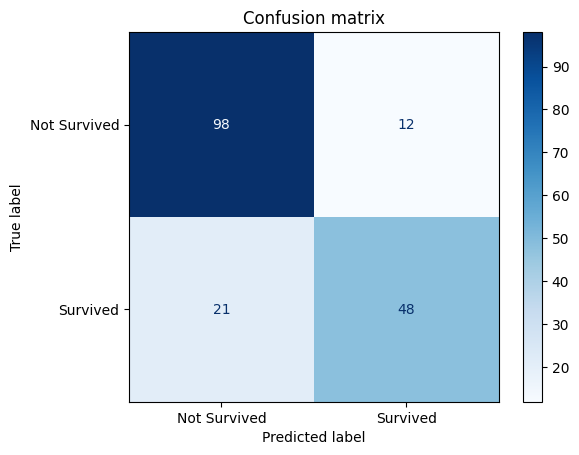

In [127]:
confm = confusion_matrix(y_test, y_pred)
displ = ConfusionMatrixDisplay(confusion_matrix=confm, display_labels=['Not Survived', 'Survived'])
displ.plot(cmap="Blues")
plt.title("Confusion matrix")
plt.show()

Note: 
- 91 passengers correctly predicted as not survived (true negative)
- 56 passengers correctly predicted as survived (true positives)

- 14 passengers predicted as survived but did not (false positive)
- 18 passengers predicted as not survived but did survive (false negative)

The model makes slightly more errors on survivors (18) than non survivors (14), but this is consistent witht the imbalance in the dataset

---

## Feature importance

Feature importance tells us how much each feature contributed to the models prediction. 

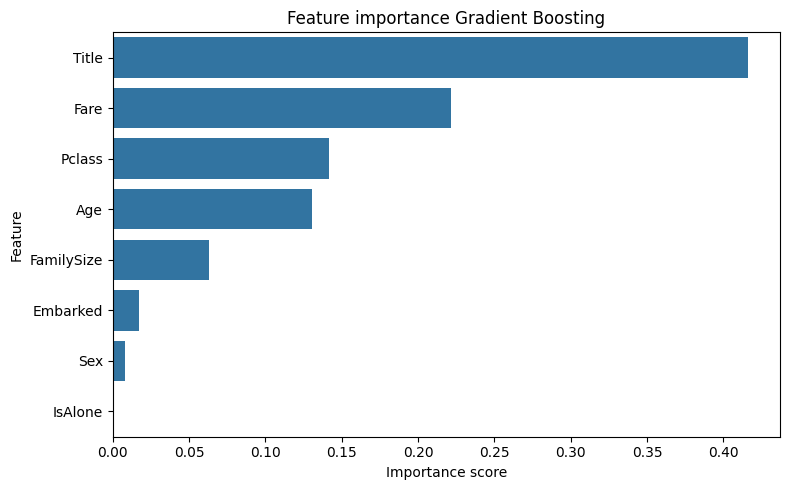

Title         0.416217
Fare          0.221446
Pclass        0.141917
Age           0.130242
FamilySize    0.063391
Embarked      0.017514
Sex           0.008195
IsAlone       0.001077
dtype: float64


In [128]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title("Feature importance Gradient Boosting")
plt.xlabel("Importance score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print(feature_importance)

Overall the model relies most heavily on Title, Fare and Pclass, which all of them reflect the social hierachy, and played a decisive role in survivng. 

### Feature Selection

Some features contributed very little, so gonna try to remove the lowest features to improve performance. 

In [129]:
#Drop less significant features
X_reduced = X.drop(columns=['IsAlone', 'Sex', 'Embarked'])
X_test_reduced = X_test_final.drop(columns=['IsAlone', 'Sex', 'Embarked'])

gb_reduced = GradientBoostingClassifier(
    learning_rate=0.1, max_depth=4, n_estimators=100, random_state=42
)

scores_reduced = cross_val_score(gb_reduced, X_reduced, y, cv=5, scoring='accuracy')

print("Reduced features CV scores:", scores_reduced)
print("Mean Accuracy:", round(scores_reduced.mean(), 4))
print("Std Deviation:", round(scores_reduced.std(), 4))

Reduced features CV scores: [0.8547486  0.80337079 0.87640449 0.82022472 0.85393258]
Mean Accuracy: 0.8417
Std Deviation: 0.0263


Removing these features were not that helpful the accuracy went up by 0.1% but the sted dev is higher so the model becomes less stable. 

Therefore it's best to keep these features.

## Kaggle Submission

In [130]:
# Train on full training data with tuned hyperparameters
final_model = GradientBoostingClassifier(
    learning_rate=0.1, max_depth=4, n_estimators=100, random_state=42
)
final_model.fit(X, y)

# Generate predictions on test set
test_predictions = final_model.predict(X_test_final)

# Create submission file
submission = pd.DataFrame({
    'PassengerId': pd.read_csv('test.csv')['PassengerId'],
    'Survived': test_predictions
})

submission.to_csv('submission.csv', index=False)
print(submission.head(10))
print(f"\nSubmission saved — {len(submission)} predictions made")

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         0
7          899         0
8          900         1
9          901         0

Submission saved — 418 predictions made


## Sources: 
- Kaggle Titanic dataset: https://www.kaggle.com/c/titanic
- Pandas documentation: https://pandas.pydata.org/docs
- Scikit-learn documentation: https://scikit-learn.org/stable
- Seaborn documentation: https://seaborn.pydata.org
- Hall, W. (1986). Social class and survival on the S.S. Titanic. 
  Social Science & Medicine, 22(6), 687-690. 
  https://pubmed.ncbi.nlm.nih.gov/3520835/

AI assistance: Claude and ChatGPT used for guidance on data cleaning, 
feature engineering, model building and evaluation.